# 01 — Exploratory Data Analysis
D-Fire dataset: class distribution, image stats, bounding box analysis.
Run `--mock` mode first; re-run on full processed data after `prepare_dataset.py`.

In [1]:
import os
import sys
from pathlib import Path

# Change working directory to repo root so all relative paths resolve correctly
repo_root = Path.cwd().parent
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.utils.paths import DATA_MOCK, DATA_PROCESSED, MOCK_DATASET_YAML, DATASET_YAML

# Toggle: set to False once prepare_dataset.py has been run on full D-Fire
USE_MOCK = not (DATA_PROCESSED / "images/train").exists()
DATA_DIR = DATA_MOCK if USE_MOCK else DATA_PROCESSED
YAML_PATH = MOCK_DATASET_YAML if USE_MOCK else DATASET_YAML
print(f"Using: {DATA_DIR}  (mock={USE_MOCK})")

Using: data/mock  (mock=True)


In [2]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

cfg = yaml.safe_load(YAML_PATH.read_text())
CLASS_NAMES = cfg["names"]
print("Classes:", CLASS_NAMES)
print("nc     :", cfg["nc"])

Classes: ['fire', 'smoke']
nc     : 2


## 1. Count images and labels per split

In [3]:
def get_image_classes(lbl_path):
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        return set()
    classes = set()
    for line in lbl_path.read_text().strip().splitlines():
        parts = line.split()
        if parts:
            classes.add(int(parts[0]))
    return classes

records = []
for split in ["train", "val", "test"]:
    img_dir = DATA_DIR / f"images/{split}"
    lbl_dir = DATA_DIR / f"labels/{split}"
    for img in sorted(img_dir.glob("*.jpg")):
        lbl = lbl_dir / f"{img.stem}.txt"
        classes = get_image_classes(lbl)
        records.append({
            "split":     split,
            "image":     img.name,
            "has_fire":  0 in classes,
            "has_smoke": 1 in classes,
            "n_boxes":   sum(1 for _ in lbl.read_text().strip().splitlines()) if lbl.exists() and lbl.stat().st_size else 0,
        })

df = pd.DataFrame(records)
print(df.groupby("split")[["has_fire","has_smoke","n_boxes"]].agg({"has_fire":"sum","has_smoke":"sum","n_boxes":"sum"}).assign(total=df.groupby("split").size()))
print(f"\nTotal images: {len(df)}")

       has_fire  has_smoke  n_boxes  total
split                                     
test          1          1        2      2
train         2          2        4      6
val           1          1        2      2

Total images: 10


## 2. Class distribution bar chart

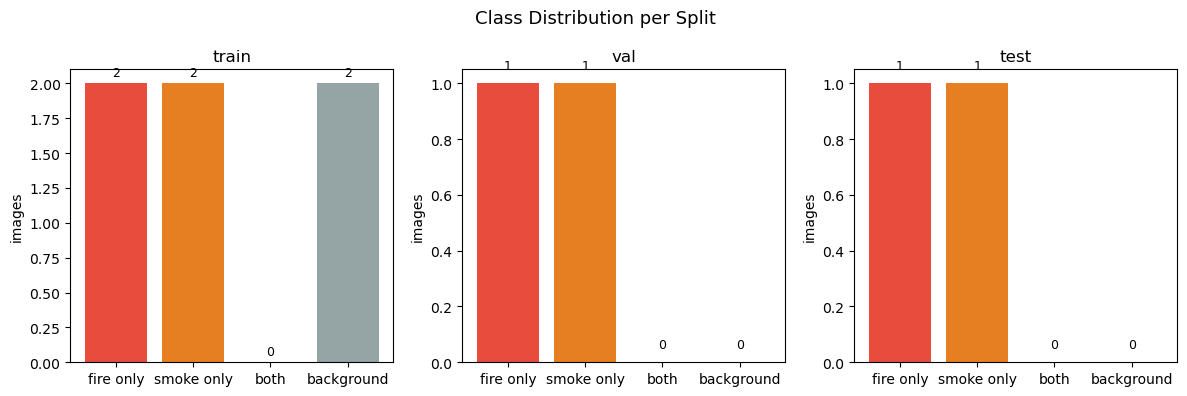

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
colors = ["#e74c3c", "#e67e22", "#95a5a6"]

for ax, split in zip(axes, ["train", "val", "test"]):
    sub = df[df["split"] == split]
    fire_only  = ((sub["has_fire"]) & (~sub["has_smoke"])).sum()
    smoke_only = ((~sub["has_fire"]) & (sub["has_smoke"])).sum()
    both       = ((sub["has_fire"]) & (sub["has_smoke"])).sum()
    neither    = ((~sub["has_fire"]) & (~sub["has_smoke"])).sum()
    vals   = [fire_only, smoke_only, both, neither]
    labels = ["fire only", "smoke only", "both", "background"]
    bar_colors = ["#e74c3c", "#e67e22", "#c0392b", "#95a5a6"]
    ax.bar(labels, vals, color=bar_colors)
    ax.set_title(split)
    ax.set_ylabel("images")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.05, str(v), ha="center", fontsize=9)

plt.suptitle("Class Distribution per Split", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Bounding box size distribution

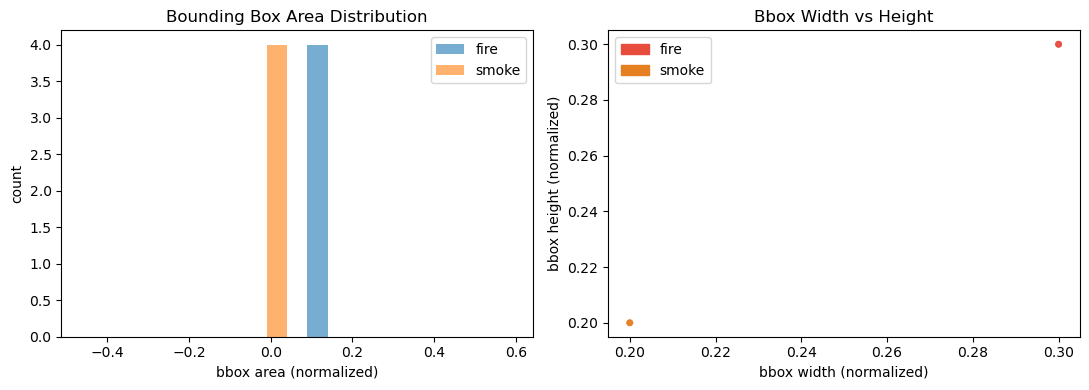

          w                                        h       ...            \
      count mean  std  min  25%  50%  75%  max count mean  ...  75%  max   
class                                                      ...             
fire    4.0  0.3  0.0  0.3  0.3  0.3  0.3  0.3   4.0  0.3  ...  0.3  0.3   
smoke   4.0  0.2  0.0  0.2  0.2  0.2  0.2  0.2   4.0  0.2  ...  0.2  0.2   

       area                                           
      count  mean  std   min   25%   50%   75%   max  
class                                                 
fire    4.0  0.09  0.0  0.09  0.09  0.09  0.09  0.09  
smoke   4.0  0.04  0.0  0.04  0.04  0.04  0.04  0.04  

[2 rows x 24 columns]


In [5]:
box_records = []
for split in ["train", "val", "test"]:
    lbl_dir = DATA_DIR / f"labels/{split}"
    for lbl in sorted(lbl_dir.glob("*.txt")):
        if lbl.stat().st_size == 0:
            continue
        for line in lbl.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) == 5:
                cls, cx, cy, w, h = int(parts[0]), *map(float, parts[1:])
                box_records.append({"split": split, "class": CLASS_NAMES[cls],
                                     "cx": cx, "cy": cy, "w": w, "h": h,
                                     "area": w * h})

bdf = pd.DataFrame(box_records)
if bdf.empty:
    print("No boxes found — check label files.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for cls_name, grp in bdf.groupby("class"):
        axes[0].hist(grp["area"], bins=20, alpha=0.6, label=cls_name)
    axes[0].set_xlabel("bbox area (normalized)")
    axes[0].set_ylabel("count")
    axes[0].set_title("Bounding Box Area Distribution")
    axes[0].legend()

    axes[1].scatter(bdf["w"], bdf["h"],
                    c=["#e74c3c" if c == "fire" else "#e67e22" for c in bdf["class"]],
                    alpha=0.5, s=15)
    axes[1].set_xlabel("bbox width (normalized)")
    axes[1].set_ylabel("bbox height (normalized)")
    axes[1].set_title("Bbox Width vs Height")
    fire_patch  = mpatches.Patch(color="#e74c3c", label="fire")
    smoke_patch = mpatches.Patch(color="#e67e22", label="smoke")
    axes[1].legend(handles=[fire_patch, smoke_patch])

    plt.tight_layout()
    plt.show()
    print(bdf.groupby("class")[["w","h","area"]].describe().round(3))

## 4. Sample images with bounding boxes

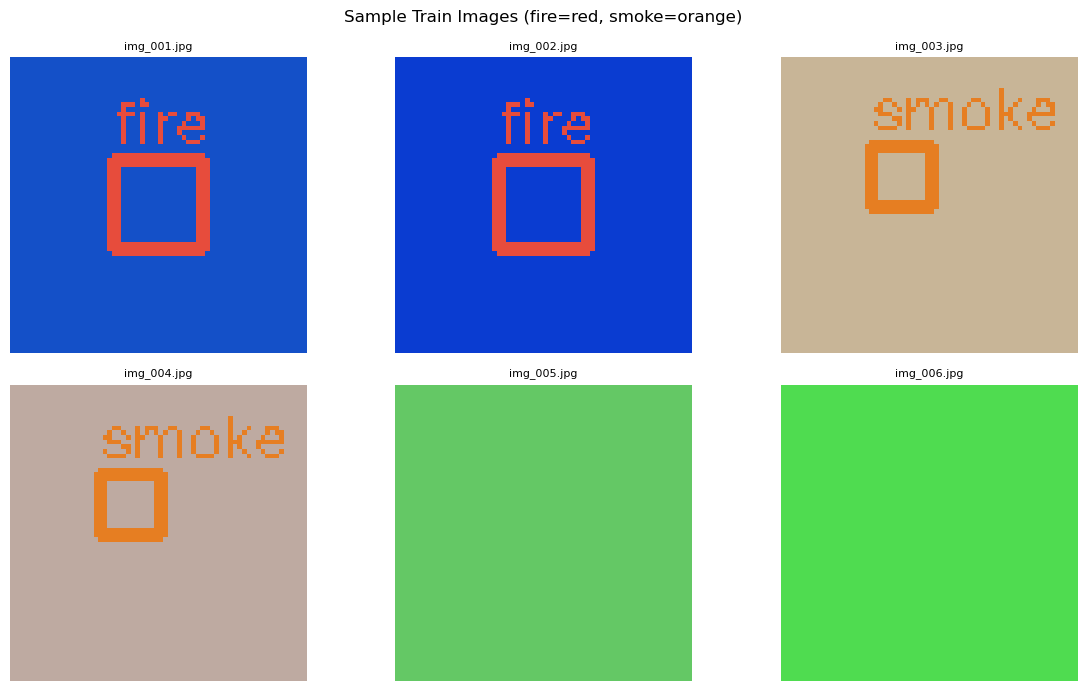

In [6]:
CLASS_COLORS = {0: (231, 76, 60), 1: (230, 126, 34)}  # fire=red, smoke=orange (RGB)

train_imgs = sorted((DATA_DIR / "images/train").glob("*.jpg"))
sample = train_imgs[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, img_path in zip(axes.flat, sample):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    lbl_path = DATA_DIR / f"labels/train/{img_path.stem}.txt"
    if lbl_path.exists() and lbl_path.stat().st_size:
        for line in lbl_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) == 5:
                cls, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                x2 = int((cx + bw / 2) * w)
                y2 = int((cy + bh / 2) * h)
                color = CLASS_COLORS.get(cls, (128, 128, 128))
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img_rgb, CLASS_NAMES[cls], (x1, max(y1 - 4, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

    ax.imshow(img_rgb)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.suptitle("Sample Train Images (fire=red, smoke=orange)", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Summary table

In [7]:
summary_rows = []
for split in ["train", "val", "test"]:
    sub = df[df["split"] == split]
    summary_rows.append({
        "split":      split,
        "total":      len(sub),
        "fire":       sub["has_fire"].sum(),
        "smoke":      sub["has_smoke"].sum(),
        "both":       ((sub["has_fire"]) & (sub["has_smoke"])).sum(),
        "background": ((~sub["has_fire"]) & (~sub["has_smoke"])).sum(),
    })

summary = pd.DataFrame(summary_rows).set_index("split")
summary.loc["TOTAL"] = summary.sum()
print(summary.to_string())

       total  fire  smoke  both  background
split                                      
train      6     2      2     0           2
val        2     1      1     0           0
test       2     1      1     0           0
TOTAL     10     4      4     0           2
